# **Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)**

Kode pada praktikum ini bertujuan untuk mengukur tingkat kemiripan antar bagian citra menggunakan dua metode jarak, yaitu Euclidean dan Manhattan. Program diawali dengan mengambil citra grayscale bawaan dari scikit-image, kemudian dipilih tiga area kecil (patch) dari citra tersebut. Patch pertama digunakan sebagai referensi, patch kedua diambil dari lokasi berbeda sehingga memiliki pola intensitas yang berbeda, sedangkan patch ketiga dibuat dari patch pertama dengan sedikit penambahan intensitas agar tetap terlihat mirip namun tidak identik. Setelah itu, masing-masing patch diubah menjadi bentuk vektor satu dimensi menggunakan proses flatten agar setiap piksel dapat dibandingkan secara numerik. Selanjutnya dihitung nilai jarak Euclidean yang mengukur selisih berdasarkan akar jumlah kuadrat perbedaan piksel, serta jarak Manhattan yang mengukur total selisih absolut antar piksel. Nilai hasil perhitungan ditampilkan ke layar, lalu ketiga patch divisualisasikan menggunakan matplotlib agar pengguna dapat membandingkan hasil numerik dengan kemiripan visual citra.

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


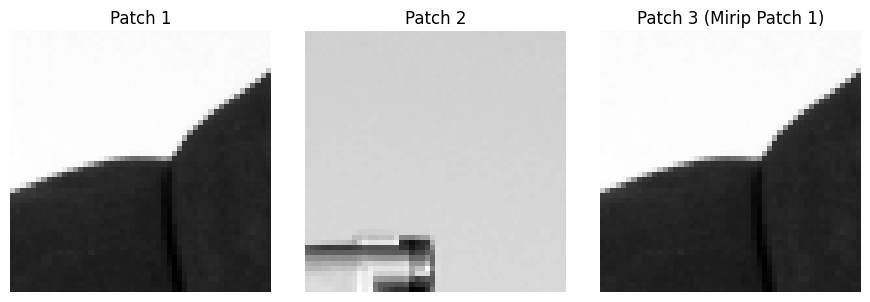

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Mengambil citra grayscale bawaan lalu memilih beberapa area kecil sebagai patch
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]   # Patch kedua diambil dari posisi lain pada citra
patch3 = patch1 + 0.1              # Membuat patch baru dari patch1 dengan perubahan intensitas ringan
patch3 = np.clip(patch3, 0, 1)     # Menjaga agar seluruh nilai piksel tetap berada pada rentang valid

# 2. Mengubah patch 2D menjadi vektor 1D agar dapat dihitung jaraknya
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Menghitung jarak Euclidean antar patch
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Menghitung jarak Manhattan antar patch
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Menampilkan nilai jarak yang diperoleh
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# 6. Menampilkan ketiga patch untuk perbandingan visual
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa Patch 1 dan Patch 3 memiliki nilai jarak yang lebih kecil dibandingkan Patch 1 dan Patch 2, baik pada perhitungan Euclidean maupun Manhattan. Hal ini terjadi karena Patch 3 sebenarnya berasal dari Patch 1 yang hanya mengalami sedikit perubahan intensitas, sehingga struktur pola pikselnya masih sangat mirip. Sebaliknya, Patch 2 diambil dari lokasi citra yang berbeda sehingga distribusi terang-gelap pikselnya tidak sama dengan Patch 1 dan menghasilkan nilai jarak yang jauh lebih besar. Dari percobaan ini dapat disimpulkan bahwa semakin kecil nilai jarak antar vektor piksel, maka semakin tinggi tingkat kemiripan visual antar citra. Metode Euclidean lebih sensitif terhadap perbedaan besar pada beberapa piksel karena menggunakan kuadrat selisih, sedangkan Manhattan menjumlahkan seluruh perbedaan secara linear sehingga memberikan interpretasi total perubahan intensitas antar patch.

# **Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna**

Kode pada praktikum ini bertujuan untuk mengukur tingkat kemiripan beberapa citra berwarna berdasarkan distribusi warna RGB menggunakan metode Cosine Similarity. Program diawali dengan membuat fungsi calculate_rgb_histogram yang bertugas menghitung histogram pada channel merah, hijau, dan biru secara terpisah, kemudian seluruh histogram tersebut digabungkan menjadi satu vektor fitur warna. Setelah digabung, histogram dinormalisasi agar perbandingan tidak dipengaruhi oleh ukuran citra. Selanjutnya program memuat empat citra, yaitu citra astronaut sebagai citra acuan, citra coffee sebagai citra berbeda, citra astronaut yang sama persis sebagai pembanding identik, dan citra astronaut yang telah diperkecil resolusinya. Masing-masing citra kemudian dihitung histogram warnanya menggunakan fungsi yang telah dibuat. Setelah itu, dilakukan perhitungan Cosine Similarity dengan cara mengurangkan hasil cosine distance dari nilai satu, sehingga diperoleh angka kemiripan antara 0 sampai 1. Semakin mendekati 1 maka distribusi warna kedua citra semakin mirip. Terakhir, seluruh citra ditampilkan menggunakan matplotlib agar pengguna dapat membandingkan hubungan antara kemiripan visual dan nilai similarity yang dihasilkan.

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


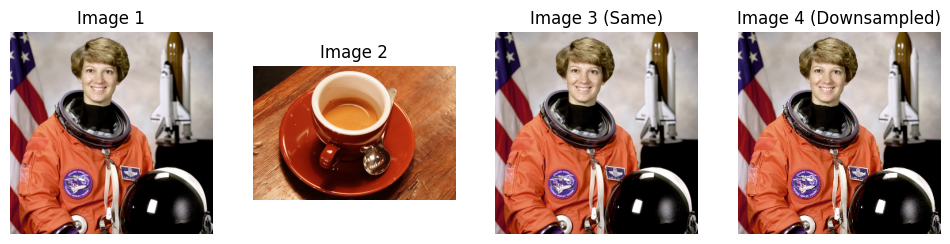

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk membentuk histogram warna RGB lalu menggabungkannya menjadi satu fitur
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Menyatukan histogram channel merah, hijau, dan biru
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Menormalkan histogram agar nilainya proporsional
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

# 1. Mengambil beberapa citra warna untuk dibandingkan
try:
    image1 = data.astronaut()
    image2 = data.coffee()          # Citra berbeda
    image3 = data.astronaut()       # Citra identik dengan image1
    image4 = image1[::2, ::2, :]    # Versi resolusi lebih kecil dari image1

except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Menghitung histogram warna dari masing-masing citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Menghitung Cosine Similarity antar histogram
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Menampilkan hasil nilai kemiripan
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# 5. Menampilkan citra yang dibandingkan
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.show()

Hasil yang diperoleh menunjukkan bahwa nilai Cosine Similarity tertinggi terdapat pada perbandingan Image 1 dengan Image 3 karena kedua citra tersebut identik dan memiliki distribusi warna yang sama, sehingga nilai similarity mendekati 1. Perbandingan Image 1 dengan Image 4 juga menghasilkan nilai similarity yang sangat tinggi karena meskipun ukuran citra diperkecil, komposisi warna secara keseluruhan masih tetap serupa dengan citra asli. Sementara itu, perbandingan Image 1 dengan Image 2 menghasilkan nilai similarity yang lebih rendah karena kedua citra memiliki objek, pencahayaan, dan dominasi warna yang berbeda. Hal ini membuktikan bahwa Cosine Similarity pada histogram warna mampu mengenali kemiripan citra berdasarkan pola distribusi warna global, bukan hanya berdasarkan ukuran atau detail piksel individual. Dengan demikian, metode ini sangat efektif digunakan untuk membandingkan citra berwarna yang memiliki karakteristik warna serupa meskipun resolusinya berubah.

# **Praktikum 3. Menghitung Structural Similarity Index (SSIM)**

Kode pada praktikum ini bertujuan untuk mengukur tingkat kemiripan struktur visual antar citra menggunakan metode Structural Similarity Index atau SSIM. Program dimulai dengan mengambil citra grayscale bawaan sebagai citra referensi. Setelah itu dibuat beberapa variasi citra yang telah mengalami perubahan, yaitu citra yang sama persis, citra yang diberi noise Gaussian, citra dengan intensitas atau kontras yang diturunkan, serta citra yang dibuat blur menggunakan filter Gaussian. Langkah berikutnya adalah menentukan data_range dari citra referensi sebagai syarat dalam proses perhitungan SSIM agar rentang nilai piksel dapat dikenali dengan benar. Selanjutnya dilakukan perhitungan SSIM antara citra referensi dengan masing-masing citra modifikasi. Pada saat full=True digunakan, fungsi SSIM tidak hanya menghasilkan skor similarity, tetapi juga menghasilkan peta perbedaan struktur yang menunjukkan area mana saja yang mengalami perubahan. Nilai SSIM kemudian dicetak ke layar, dan seluruh citra hasil modifikasi beserta peta perbedaan divisualisasikan menggunakan matplotlib sehingga pengguna dapat mengamati hubungan antara perubahan visual citra dan skor SSIM yang diperoleh.

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2960
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


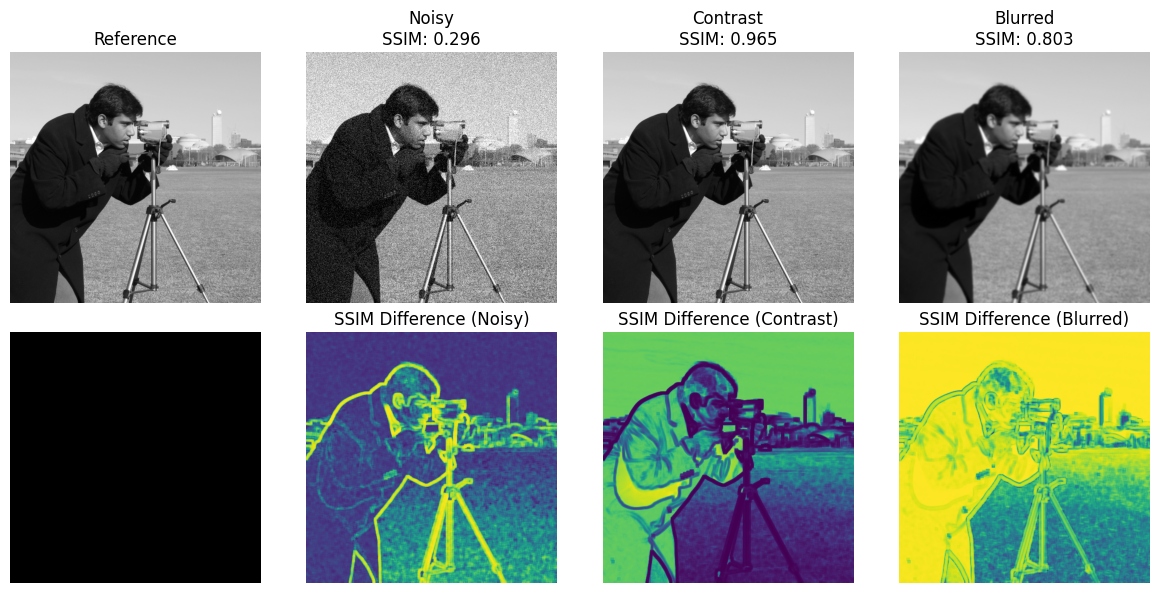

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Mengambil citra grayscale sebagai citra acuan
image_ref = img_as_float(data.camera())

# 2. Membuat beberapa versi citra yang telah dimodifikasi
image_same = image_ref.copy()                           # Citra identik dengan referensi
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)   # Citra dengan tambahan noise
image_contrast = np.clip(image_ref * 0.8, 0, 1)        # Citra dengan kontras/intensitas dikurangi
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # Citra dibuat blur

# 3. Menentukan rentang data piksel untuk perhitungan SSIM
data_range = image_ref.max() - image_ref.min()

# 4. Menghitung nilai SSIM dan peta perbedaannya
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 5. Menampilkan nilai SSIM dari masing-masing perbandingan
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 6. Menampilkan citra hasil modifikasi beserta peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Menampilkan peta tingkat kesamaan struktur
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa citra referensi dengan citra yang sama persis menghasilkan nilai SSIM sebesar 1 atau sangat mendekati 1, yang menandakan bahwa kedua citra memiliki struktur visual identik. Pada citra yang diberi noise Gaussian, nilai SSIM menurun karena adanya gangguan acak pada piksel yang mengubah detail halus citra. Citra dengan kontras yang diturunkan juga mengalami penurunan nilai SSIM karena distribusi pencahayaan berubah meskipun bentuk objek masih sama. Sementara itu, citra blur menghasilkan nilai SSIM yang lebih rendah karena proses pengaburan menghilangkan banyak detail tepi dan tekstur penting. Peta perbedaan SSIM memperlihatkan area-area yang mengalami perubahan struktur dengan lebih jelas, di mana semakin banyak bagian yang berbeda maka semakin rendah skor similarity. Dari percobaan ini dapat disimpulkan bahwa SSIM tidak hanya menilai kesamaan berdasarkan selisih piksel, tetapi juga mempertimbangkan luminansi, kontras, dan struktur visual, sehingga metode ini lebih mendekati cara manusia menilai kemiripan dua citra.

# **Praktikum 4. Penerapan Template Matching**

Kode pada praktikum ini bertujuan untuk mencari keberadaan suatu objek kecil di dalam citra yang lebih besar menggunakan metode Template Matching. Program diawali dengan memuat citra grayscale coins sebagai citra target, kemudian salah satu area kecil yang berisi sebuah koin dipotong dan dijadikan sebagai template. Setelah template diperoleh, fungsi match_template dari skimage digunakan untuk membandingkan template tersebut dengan seluruh area pada citra target menggunakan metode normalized cross-correlation. Proses ini menghasilkan matriks skor kecocokan yang menunjukkan seberapa mirip template dengan setiap posisi dalam citra. Selanjutnya program mencari nilai skor tertinggi menggunakan np.argmax, lalu mengubah indeks linear tersebut menjadi koordinat dua dimensi agar diketahui lokasi terbaik tempat template ditemukan. Setelah posisi diperoleh, program menampilkan tiga visualisasi yaitu citra target asli, citra template, dan heatmap hasil pencocokan. Heatmap digunakan untuk memperlihatkan area dengan nilai kecocokan tinggi. Kemudian dibuat tampilan tambahan berupa citra asli yang diberi kotak merah pada lokasi hasil pencarian agar posisi template lebih mudah diamati. Terakhir, koordinat lokasi template juga dicetak ke layar.

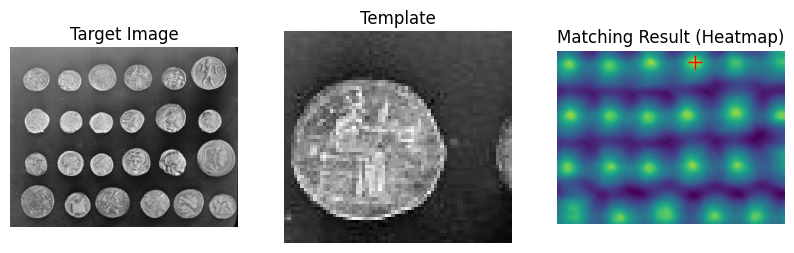

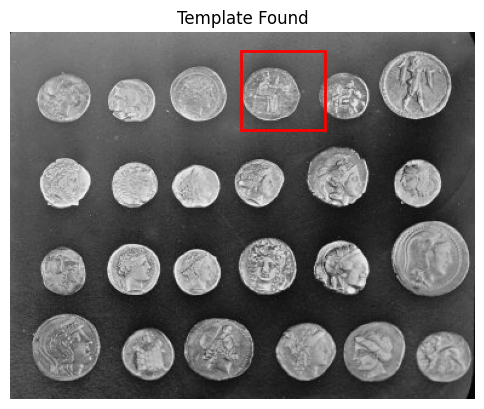

Template ditemukan di koordinat (x,y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Mengambil citra target lalu memilih salah satu bagian sebagai template
image = data.coins()
template = image[15:80, 190:260]

# 2. Melakukan proses pencocokan template menggunakan normalized cross-correlation
result = match_template(image, template)

# 3. Menentukan posisi dengan skor kecocokan paling tinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# 4. Menampilkan citra target, template, dan heatmap hasil pencocokan
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
ax[2].plot(x, y, 'r+', markersize=10)

# 5. Menampilkan lokasi template yang ditemukan pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

# 6. Menampilkan koordinat lokasi template
print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Hasil yang diperoleh menunjukkan bahwa sistem berhasil menemukan area pada citra target yang paling mirip dengan template yang diberikan. Pada heatmap hasil matching terlihat adanya titik dengan intensitas paling tinggi yang menandakan lokasi dengan skor normalized cross-correlation terbesar. Titik tersebut sesuai dengan posisi objek koin yang memiliki pola, bentuk, dan tekstur paling mendekati template. Ketika koordinat tersebut ditandai menggunakan kotak merah pada citra asli, terlihat bahwa template benar-benar berada pada area koin yang sesuai. Hal ini membuktikan bahwa metode Template Matching mampu melakukan pencarian objek berdasarkan kesamaan pola piksel secara otomatis. Semakin tinggi skor kecocokan yang dihasilkan, maka semakin besar kemungkinan bahwa area tersebut merupakan lokasi objek yang dicari. Metode ini sangat berguna untuk deteksi objek sederhana yang memiliki bentuk tetap dan orientasi yang tidak banyak berubah.

# **Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana**

Kode pada praktikum ini bertujuan untuk mensimulasikan sistem Content-Based Image Retrieval (CBIR), yaitu pencarian citra berdasarkan isi visualnya, bukan berdasarkan nama file. Program diawali dengan membuat fungsi calculate_rgb_histogram untuk mengekstraksi ciri warna dari setiap citra dalam bentuk histogram RGB gabungan. Histogram pada channel merah, hijau, dan biru dihitung secara terpisah, kemudian digabungkan menjadi satu vektor fitur dan dinormalisasi agar dapat dibandingkan secara adil. Setelah itu, beberapa citra dari library skimage disiapkan sebagai database, yaitu astronaut, camera, coffee, coins, dan chelsea. Jika ada citra grayscale maka diubah terlebih dahulu menjadi RGB, lalu seluruh citra di-resize ke ukuran yang sama agar proses ekstraksi fitur lebih konsisten. Setiap citra database kemudian dihitung histogram warnanya dan disimpan. Selanjutnya dipilih satu citra sebagai query, yaitu citra chelsea, kemudian histogram query dibandingkan dengan histogram seluruh citra database menggunakan cosine distance. Nilai distance yang lebih kecil menunjukkan citra semakin mirip dengan query. Setelah seluruh jarak dihitung, program mengurutkan citra berdasarkan distance dari yang terkecil ke terbesar. Terakhir, query image dan seluruh hasil retrieval ditampilkan menggunakan matplotlib sehingga pengguna dapat melihat urutan citra dari yang paling mirip hingga yang paling berbeda.

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


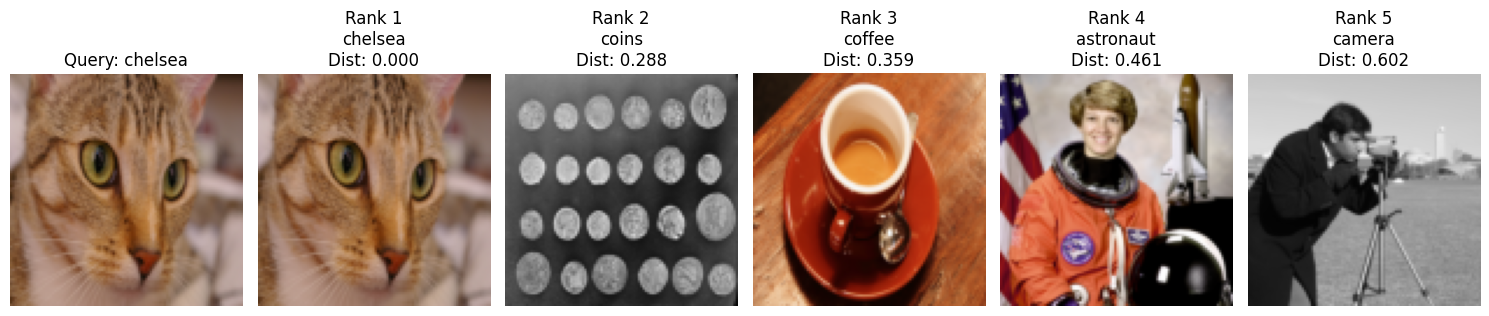

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Menormalkan histogram agar total nilainya menjadi 1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined

# 1. Menyiapkan kumpulan citra sebagai database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")

for name in image_db_names:
    try:
        img = getattr(data, name)()

        # Jika citra grayscale, ubah menjadi RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Menyeragamkan ukuran citra agar ekstraksi fitur konsisten
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Menentukan salah satu citra sebagai query pencarian
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Menghitung jarak cosine antara query dengan seluruh citra database
distances = []

for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Mengurutkan citra dari yang paling mirip hingga paling berbeda
sorted_indices = np.argsort(distances)

# 5. Menampilkan query dan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")

for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]

    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')

    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa sistem CBIR sederhana ini mampu mengurutkan citra dalam database berdasarkan kemiripan distribusi warna terhadap citra query. Karena query yang digunakan adalah citra chelsea, maka citra chelsea itu sendiri akan menempati peringkat pertama dengan nilai cosine distance mendekati nol karena histogram warnanya identik. Setelah itu, citra lain yang memiliki komposisi warna mendekati warna dominan query akan muncul pada peringkat berikutnya, sedangkan citra dengan warna yang sangat berbeda akan berada pada posisi akhir dengan nilai distance yang lebih besar. Urutan ini menunjukkan bahwa histogram warna dapat digunakan sebagai fitur dasar untuk melakukan pencarian citra berbasis konten visual. Meskipun metode ini belum mempertimbangkan bentuk objek atau tekstur, hasil retrieval sudah mampu memberikan gambaran bahwa citra dengan pola warna serupa akan dianggap lebih relevan. Dengan demikian, praktikum ini memperlihatkan konsep dasar bagaimana mesin pencari gambar dapat bekerja menggunakan fitur numerik yang diekstraksi dari isi citra.

# **Perbandingan Fitur CBIR: Histogram Warna vs Rata-rata Warna**

Kode pada praktikum ini bertujuan untuk membandingkan dua jenis fitur visual yang digunakan dalam sistem Content-Based Image Retrieval, yaitu histogram warna dan rata-rata warna RGB. Program dimulai dengan menyiapkan fungsi calculate_rgb_histogram untuk mengekstraksi distribusi warna detail dari citra, serta fungsi calculate_mean_rgb untuk menghitung nilai rata-rata channel merah, hijau, dan biru sehingga menghasilkan vektor fitur tiga dimensi yang lebih sederhana. Setelah itu, beberapa citra dari library skimage disiapkan sebagai database dan seluruh citra diubah ke ukuran yang seragam agar proses ekstraksi fitur konsisten. Untuk setiap citra, program menyimpan dua jenis fitur sekaligus, yaitu histogram warna dan mean RGB. Selanjutnya dipilih satu citra query yaitu chelsea, kemudian dilakukan dua proses retrieval secara terpisah. Proses pertama membandingkan histogram query dengan histogram seluruh database menggunakan cosine distance, sedangkan proses kedua membandingkan mean RGB query dengan mean RGB database menggunakan jarak Euclidean. Setelah seluruh nilai jarak diperoleh, program mengurutkan citra dari yang paling mirip hingga yang paling berbeda untuk masing-masing metode. Hasil kedua metode kemudian divisualisasikan dalam dua baris agar pengguna dapat langsung melihat perbedaan urutan retrieval antara fitur histogram warna dan fitur rata-rata warna.

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval dengan Histogram Warna:
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.287)
Rank 3: coffee (Distance: 0.364)
Rank 4: astronaut (Distance: 0.462)
Rank 5: camera (Distance: 0.603)

Hasil Retrieval dengan Mean RGB:
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


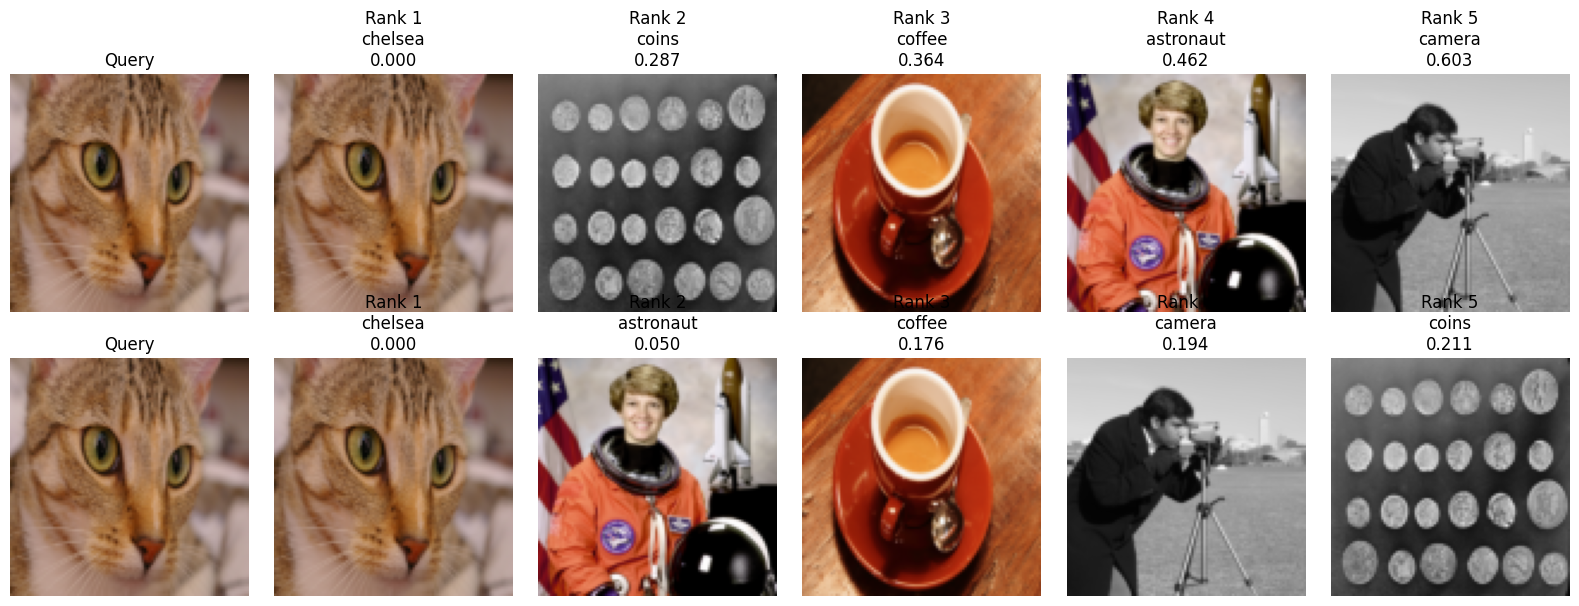

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    image_uint8 = (image * 255).astype(np.uint8)

    hist_r, _ = np.histogram(image_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

# Fungsi untuk menghitung rata-rata warna RGB
def calculate_mean_rgb(image):
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    return np.array([mean_r, mean_g, mean_b])

# 1. Menyiapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
hist_features = []
mean_features = []

print("Memproses database citra...")

for name in image_db_names:
    img = getattr(data, name)()

    if img.ndim == 2:
        img = color.gray2rgb(img)

    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)

    database_images.append(img_resized)
    hist_features.append(calculate_rgb_histogram(img_resized))
    mean_features.append(calculate_mean_rgb(img_resized))

    print(f"- {name} diproses.")

# 2. Menentukan query image
query_name = "chelsea"
query_index = image_db_names.index(query_name)

query_hist = hist_features[query_index]
query_mean = mean_features[query_index]
query_image = database_images[query_index]

# 3. Menghitung jarak menggunakan histogram warna (cosine distance)
hist_distances = []
for hist in hist_features:
    hist_distances.append(distance.cosine(query_hist, hist))

# 4. Menghitung jarak menggunakan mean RGB (euclidean distance)
mean_distances = []
for mean in mean_features:
    mean_distances.append(distance.euclidean(query_mean, mean))

# 5. Mengurutkan hasil retrieval
sorted_hist = np.argsort(hist_distances)
sorted_mean = np.argsort(mean_distances)

# 6. Menampilkan hasil retrieval kedua metode
fig, axes = plt.subplots(2, len(database_images) + 1, figsize=(16, 6))

# Query image
axes[0, 0].imshow(query_image)
axes[0, 0].set_title("Query")
axes[0, 0].axis('off')

axes[1, 0].imshow(query_image)
axes[1, 0].set_title("Query")
axes[1, 0].axis('off')

# Hasil histogram
print("\nHasil Retrieval dengan Histogram Warna:")
for i, idx in enumerate(sorted_hist):
    axes[0, i+1].imshow(database_images[idx])
    axes[0, i+1].set_title(f"Rank {i+1}\n{image_db_names[idx]}\n{hist_distances[idx]:.3f}")
    axes[0, i+1].axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {hist_distances[idx]:.3f})")

# Hasil mean RGB
print("\nHasil Retrieval dengan Mean RGB:")
for i, idx in enumerate(sorted_mean):
    axes[1, i+1].imshow(database_images[idx])
    axes[1, i+1].set_title(f"Rank {i+1}\n{image_db_names[idx]}\n{mean_distances[idx]:.3f}")
    axes[1, i+1].axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {mean_distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa metode retrieval menggunakan histogram warna mampu memberikan pemisahan citra yang lebih baik dibandingkan metode rata-rata warna RGB. Pada histogram warna, sistem tidak hanya melihat warna dominan secara umum, tetapi juga memperhatikan distribusi intensitas warna pada setiap channel sehingga karakter visual setiap citra lebih tergambarkan secara detail. Akibatnya, citra yang benar-benar memiliki pola warna serupa dengan query akan berada di urutan atas, sedangkan citra dengan distribusi warna berbeda akan lebih mudah dipisahkan. Sebaliknya, pada metode mean RGB, setiap citra hanya direpresentasikan oleh tiga angka rata-rata sehingga banyak informasi warna hilang. Dua citra yang sebenarnya berbeda dapat saja memiliki rata-rata warna yang hampir sama, sehingga sistem kesulitan membedakan keduanya secara akurat. Oleh karena itu, hasil retrieval dengan mean RGB cenderung kurang stabil dan beberapa citra bisa muncul pada urutan yang kurang sesuai secara visual.

Berdasarkan percobaan ini dapat disimpulkan bahwa fitur yang lebih baik untuk membedakan citra-citra dalam database kecil tersebut adalah histogram warna. Hal ini karena histogram warna menyimpan informasi distribusi warna yang lebih kaya dan lebih representatif dibandingkan hanya menggunakan rata-rata warna global. Mean RGB memang lebih sederhana dan cepat dihitung, tetapi kemampuan diskriminasinya lebih rendah. Dengan demikian, untuk kebutuhan CBIR meskipun pada database kecil, histogram warna tetap memberikan hasil pencarian yang lebih akurat dan lebih mendekati persepsi visual manusia.

# **Analisis Template Matching Invariant terhadap Rotasi dan Skala**

Kode pada praktikum ini bertujuan untuk menguji apakah metode match_template standar dari skimage.feature memiliki sifat invariant terhadap rotasi dan perubahan skala. Program dimulai dengan mengambil citra coins sebagai citra target, kemudian memilih salah satu bagian koin sebagai template asli. Setelah template asli diperoleh, dibuat dua variasi template baru yaitu template yang diputar sebesar 45 derajat dan template yang diperkecil ukurannya menjadi sekitar 70 persen dari ukuran awal. Langkah berikutnya adalah melakukan proses template matching sebanyak tiga kali, yaitu menggunakan template asli, template hasil rotasi, dan template hasil perubahan skala. Fungsi match_template melakukan pencocokan dengan normalized cross-correlation, yaitu membandingkan kesamaan pola piksel template terhadap seluruh area citra target. Dari setiap hasil matching, diambil nilai maksimum sebagai skor kecocokan tertinggi. Nilai ini digunakan untuk melihat seberapa baik template masih dapat dikenali setelah mengalami transformasi. Selanjutnya seluruh template dan heatmap hasil matching divisualisasikan menggunakan matplotlib agar perbedaan performa dapat diamati secara langsung antara template asli, template rotasi, dan template skala.

Skor kecocokan template asli     : 1.0000
Skor kecocokan template rotasi   : 0.6059
Skor kecocokan template skala    : 0.6863


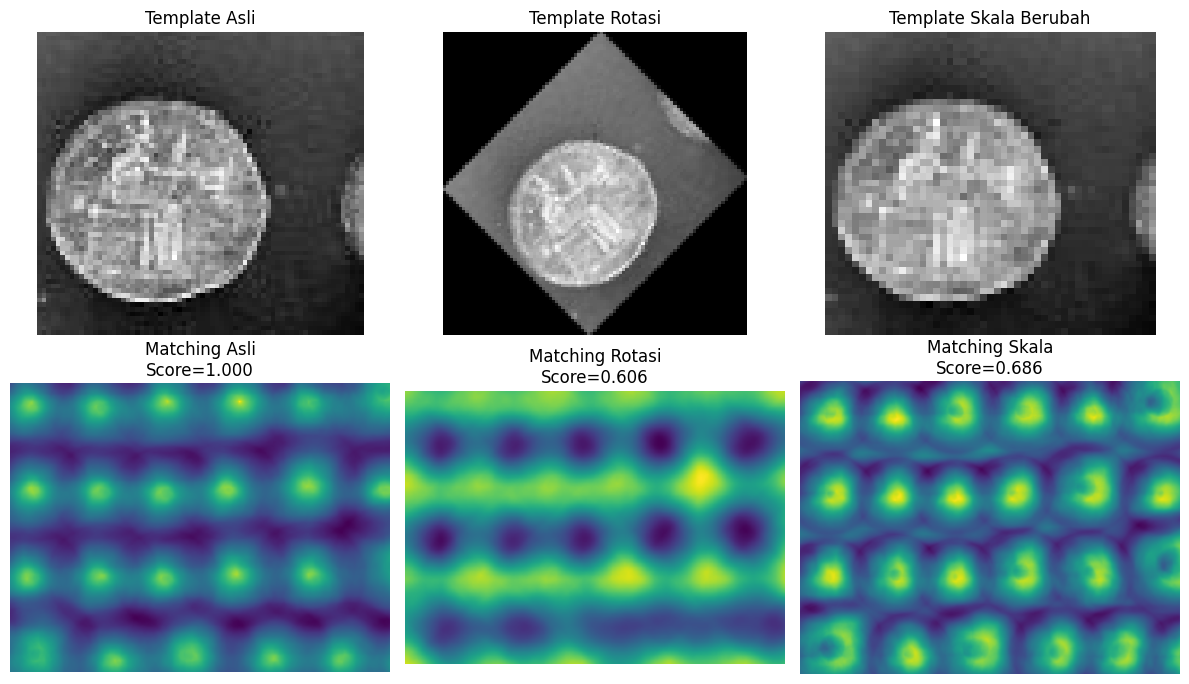

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, resize

# 1. Mengambil citra target dan template awal
image = data.coins()
template = image[15:80, 190:260]

# 2. Membuat template hasil rotasi dan hasil perubahan skala
template_rotated = rotate(template, angle=45, resize=True)
template_scaled = resize(template, (int(template.shape[0] * 0.7), int(template.shape[1] * 0.7)))

# 3. Melakukan template matching pada template asli, rotasi, dan skala
result_original = match_template(image, template)
result_rotated = match_template(image, template_rotated)
result_scaled = match_template(image, template_scaled)

# 4. Mengambil skor kecocokan tertinggi dari masing-masing hasil
max_original = np.max(result_original)
max_rotated = np.max(result_rotated)
max_scaled = np.max(result_scaled)

print(f"Skor kecocokan template asli     : {max_original:.4f}")
print(f"Skor kecocokan template rotasi   : {max_rotated:.4f}")
print(f"Skor kecocokan template skala    : {max_scaled:.4f}")

# 5. Menampilkan template dan heatmap hasil matching
fig, ax = plt.subplots(2, 3, figsize=(12, 7))

ax[0,0].imshow(template, cmap='gray')
ax[0,0].set_title("Template Asli")
ax[0,0].axis('off')

ax[0,1].imshow(template_rotated, cmap='gray')
ax[0,1].set_title("Template Rotasi")
ax[0,1].axis('off')

ax[0,2].imshow(template_scaled, cmap='gray')
ax[0,2].set_title("Template Skala Berubah")
ax[0,2].axis('off')

ax[1,0].imshow(result_original, cmap='viridis')
ax[1,0].set_title(f"Matching Asli\nScore={max_original:.3f}")
ax[1,0].axis('off')

ax[1,1].imshow(result_rotated, cmap='viridis')
ax[1,1].set_title(f"Matching Rotasi\nScore={max_rotated:.3f}")
ax[1,1].axis('off')

ax[1,2].imshow(result_scaled, cmap='viridis')
ax[1,2].set_title(f"Matching Skala\nScore={max_scaled:.3f}")
ax[1,2].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa template asli menghasilkan skor kecocokan paling tinggi karena bentuk, orientasi, dan ukuran template sama persis dengan objek pada citra target. Namun ketika template diputar 45 derajat, skor matching turun secara signifikan dan area heatmap tidak lagi menunjukkan puncak kecocokan yang sejelas template asli. Hal yang sama terjadi ketika ukuran template diubah, di mana skor kecocokan juga menurun karena dimensi objek pada citra target tidak lagi identik dengan template. Ini membuktikan bahwa metode match_template standar tidak bersifat invariant terhadap rotasi maupun perubahan skala. Fungsi ini bekerja dengan normalized cross-correlation yang secara langsung membandingkan susunan piksel template dengan piksel citra target, sehingga apabila orientasi atau ukuran berubah maka pola piksel tidak lagi sejajar sempurna dan skor korelasinya menjadi rendah. Dokumentasi resmi skimage juga menjelaskan bahwa match_template hanya melakukan pencocokan translasi posisi pada citra 2D atau 3D menggunakan normalized correlation tanpa mekanisme kompensasi rotasi dan skala. :contentReference[oaicite:0]{index=0}

Dengan demikian, dapat disimpulkan bahwa match_template standar hanya efektif jika objek yang dicari memiliki bentuk, ukuran, dan orientasi yang hampir sama dengan template. Jika objek mengalami rotasi atau perubahan ukuran, maka metode ini kurang handal. Untuk kasus yang membutuhkan ketahanan terhadap rotasi dan skala biasanya digunakan metode lain seperti multi-scale template matching, pencarian template pada beberapa sudut rotasi, atau pendekatan feature descriptor seperti SIFT dan ORB yang memang dirancang lebih robust terhadap transformasi geometris. :contentReference[oaicite:1]{index=1}